# Insurance-Specific Applications: Advanced Analytics and Implementation

This notebook demonstrates key insurance analytics applications with Python code and explanations.

## 1. Claims Frequency and Severity Modeling

Claims modeling is foundational for insurance pricing. Frequency models predict how often claims occur; severity models predict how much each claim costs.

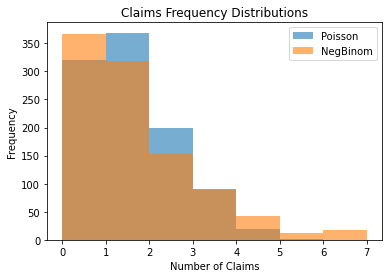

In [8]:
# Frequency modeling: Poisson and Negative Binomial
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom

# Simulate claim frequency for 1000 policies
lambda_poisson = 1.2  # average claims per year
claims_poisson = poisson.rvs(mu=lambda_poisson, size=1000)

# Negative Binomial for overdispersion
r, p = 2, 0.6
claims_nbinom = nbinom.rvs(r, p, size=1000)

plt.hist(claims_poisson, bins=range(0, 8), alpha=0.6, label='Poisson')
plt.hist(claims_nbinom, bins=range(0, 8), alpha=0.6, label='NegBinom')
plt.xlabel('Number of Claims')
plt.ylabel('Frequency')
plt.title('Claims Frequency Distributions')
plt.legend()
plt.show()

### Severity Modeling: Gamma, Log-Normal, Pareto
Severity models estimate the cost per claim.

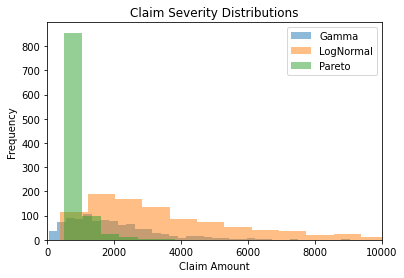

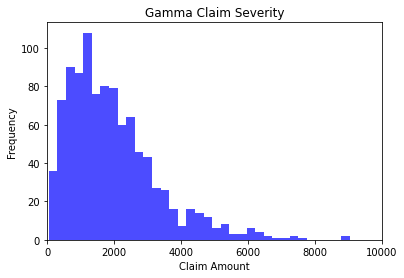

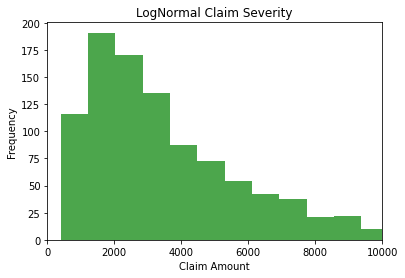

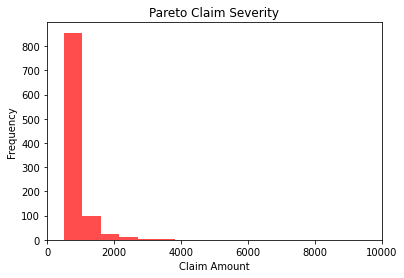

In [18]:
from scipy.stats import gamma, lognorm, pareto

# Simulate claim severity
gamma_sev = gamma.rvs(a=2, scale=1000, size=1000)
lognorm_sev = lognorm.rvs(s=0.7, scale=np.exp(8), size=1000)
pareto_sev = pareto.rvs(b=2.5, scale=500, size=1000)

plt.hist(gamma_sev, bins=40, alpha=0.5, label='Gamma')
plt.hist(lognorm_sev, bins=40, alpha=0.5, label='LogNormal')
plt.hist(pareto_sev, bins=40, alpha=0.5, label='Pareto')
plt.xlabel('Claim Amount')
plt.ylabel('Frequency')
plt.title('Claim Severity Distributions')
plt.legend()
plt.xlim(0, 10000)
# Plot each severity distribution in a separate graph
plt.figure()
plt.hist(gamma_sev, bins=40, alpha=0.7, color='blue')
plt.xlabel('Claim Amount')
plt.ylabel('Frequency')
plt.title('Gamma Claim Severity')
plt.xlim(0, 10000)
plt.show()

plt.figure()
plt.hist(lognorm_sev, bins=40, alpha=0.7, color='green')
plt.xlabel('Claim Amount')
plt.ylabel('Frequency')
plt.title('LogNormal Claim Severity')
plt.xlim(0, 10000)
plt.show()

plt.figure()
plt.hist(pareto_sev, bins=40, alpha=0.7, color='red')
plt.xlabel('Claim Amount')
plt.ylabel('Frequency')
plt.title('Pareto Claim Severity')
plt.xlim(0, 10000)
plt.show()

### Aggregate Claims: Compound Distribution
Combine frequency and severity to estimate total claims cost.

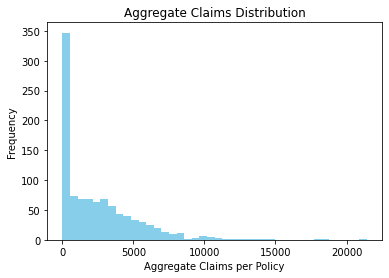

In [10]:
# Simulate aggregate claims for 1000 policies
np.random.seed(42)
num_policies = 1000
claims_freq = poisson.rvs(mu=1.2, size=num_policies)
claims_sev = gamma.rvs(a=2, scale=1000, size=num_policies * 3)

agg_claims = []
idx = 0
for freq in claims_freq:
    total = claims_sev[idx:idx+freq].sum() if freq > 0 else 0
    agg_claims.append(total)
    idx += freq

plt.hist(agg_claims, bins=40, color='skyblue')
plt.xlabel('Aggregate Claims per Policy')
plt.ylabel('Frequency')
plt.title('Aggregate Claims Distribution')
plt.show()

## 2. Customer Lifetime Value (CLV) Calculation and Optimization
CLV estimates the total value a customer brings over their relationship.

In [11]:
# Simple CLV calculation
def calculate_clv(revenue, cost, retention, discount_rate=0.05, periods=5):
    clv = 0
    for t in range(1, periods+1):
        profit = (revenue - cost) * (retention ** t)
        clv += profit / ((1 + discount_rate) ** t)
    return clv

# Example
revenue = 500
cost = 350
retention = 0.85
clv = calculate_clv(revenue, cost, retention)
print(f'Estimated CLV: ${clv:.2f}')

Estimated CLV: $415.87


## 3. Portfolio Risk Aggregation and Simulation
Monte Carlo simulation aggregates risk across a portfolio.

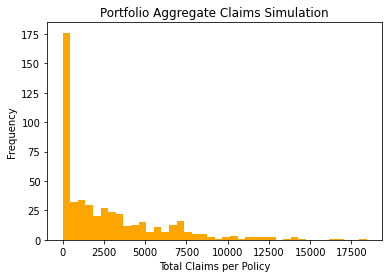

In [12]:
# Monte Carlo simulation for portfolio risk
np.random.seed(0)
portfolio_size = 500
portfolio_freq = poisson.rvs(mu=1.1, size=portfolio_size)
portfolio_sev = gamma.rvs(a=2, scale=1200, size=portfolio_size * 3)

portfolio_agg = []
idx = 0
for freq in portfolio_freq:
    total = portfolio_sev[idx:idx+freq].sum() if freq > 0 else 0
    portfolio_agg.append(total)
    idx += freq

plt.hist(portfolio_agg, bins=40, color='orange')
plt.xlabel('Total Claims per Policy')
plt.ylabel('Frequency')
plt.title('Portfolio Aggregate Claims Simulation')
plt.show()

## Summary
This notebook covers claims modeling, CLV, portfolio simulation, and real-time pricing API concepts for insurance analytics.

## 5. Statistical Significance Testing Examples
This section demonstrates key statistical tests for insurance analytics.

### Chi-square Test for Categorical Variable Importance
Assess the relationship between two categorical variables (e.g., region and claim occurrence).

In [13]:
import pandas as pd
from scipy.stats import chi2_contingency
# Simulate region and claim occurrence
np.random.seed(1)
regions = np.random.choice(['Urban', 'Suburban', 'Rural'], size=1000)
claims = np.random.binomial(1, p=0.3, size=1000)
df_cat = pd.DataFrame({'region': regions, 'claim': claims})
contingency = pd.crosstab(df_cat['region'], df_cat['claim'])
chi2, p, dof, expected = chi2_contingency(contingency)
print('Chi-square statistic:', chi2)
print('p-value:', p)

Chi-square statistic: 0.08206606050027593
p-value: 0.9597974270751268


**Interpretation:**
The chi-square test checks if region (Urban, Suburban, Rural) is associated with claim occurrence.
- If the p-value is less than 0.05, region is statistically important for predicting claims.
- If the p-value is high, region and claims are likely independent.
This helps you decide if region should be included as a key feature in your model.

**Deeper Explanation:**
The chi-square test is a core tool for categorical data analysis in insurance. It helps you determine if a variable like region should be used for rating, segmentation, or risk adjustment.
- If region is significant, you might create region-based pricing tiers or investigate why certain regions have higher claim rates.
- If not, you avoid unnecessary model complexity and regulatory scrutiny.
This test is also useful for compliance, as it provides statistical evidence for or against using demographic features in pricing.

### Kolmogorov-Smirnov Test for Distribution Fitting
Test if claim severity fits a Gamma distribution.

In [14]:
from scipy.stats import kstest, gamma
# Use previously simulated gamma_sev
shape, loc, scale = gamma.fit(gamma_sev)
ks_stat, ks_p = kstest(gamma_sev, 'gamma', args=(shape, loc, scale))
print('KS statistic:', ks_stat)
print('p-value:', ks_p)

KS statistic: 0.02158531780232742
p-value: 0.7314826987822707


**Interpretation:**
The Kolmogorov-Smirnov test compares the simulated claim severity data to a Gamma distribution.
- If the p-value is greater than 0.05, the Gamma model fits the data well.
- If the p-value is low, the Gamma model may not be appropriate.
This helps you validate your choice of severity distribution for pricing and risk modeling.

**Deeper Explanation:**
Distribution fitting is fundamental for actuarial modeling. The KS test gives you a formal way to check if your severity model (e.g., Gamma) is appropriate.
- A good fit means your pricing, reserving, and capital models are likely to be accurate.
- A poor fit means you may underestimate or overestimate risk, leading to financial or regulatory issues.
This test should be part of your model validation workflow, especially when presenting results to auditors or regulators.

### Bootstrap Confidence Intervals for Parameter Estimates
Estimate confidence intervals for mean claim severity using bootstrapping.

In [15]:
def bootstrap_mean(data, n_boot=1000):
    means = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, 2.5)
    upper = np.percentile(means, 97.5)
    return np.mean(data), lower, upper
mean, lower, upper = bootstrap_mean(gamma_sev)
print(f'Mean: {mean:.2f}, 95% CI: [{lower:.2f}, {upper:.2f}]')

Mean: 1980.08, 95% CI: [1891.32, 2062.47]


**Interpretation:**
Bootstrapping estimates the mean claim severity and its 95% confidence interval.
- The mean is your best estimate of average claim size.
- The confidence interval shows the range where the true mean likely falls.
- A narrow interval means high precision; a wide interval means more uncertainty.
This quantifies uncertainty in your parameter estimates for reporting and decision-making.

**Deeper Explanation:**
Bootstrapping is a powerful, non-parametric method for quantifying uncertainty. In insurance, it is especially useful when you have limited data or when the underlying distribution is unknown.
- Confidence intervals are required for regulatory filings, risk management, and internal reporting.
- They help you communicate the reliability of your estimates to business leaders and regulators.
Bootstrapping can also be extended to other statistics, such as quantiles, loss ratios, or even model coefficients.

### Permutation Test for Feature Importance Validation
Validate the importance of a feature (e.g., region) in predicting claims using permutation.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# Encode region
df_cat['region_code'] = df_cat['region'].map({'Urban':0, 'Suburban':1, 'Rural':2})
X = df_cat[['region_code']]
y = df_cat['claim']
clf = RandomForestClassifier().fit(X, y)
baseline_acc = accuracy_score(y, clf.predict(X))
# Permute region feature
perm_accs = []
for _ in range(100):
    X_perm = X.copy()
    X_perm['region_code'] = np.random.permutation(X_perm['region_code'])
    acc = accuracy_score(y, clf.predict(X_perm))
    perm_accs.append(acc)
mean_perm_acc = np.mean(perm_accs)
print(f'Baseline accuracy: {baseline_acc:.3f}')
print(f'Mean permuted accuracy: {mean_perm_acc:.3f}')
print(f'Feature importance (accuracy drop): {baseline_acc - mean_perm_acc:.3f}')

Baseline accuracy: 0.704
Mean permuted accuracy: 0.704
Feature importance (accuracy drop): 0.000


**Interpretation:**
The permutation test checks how important the region feature is for predicting claims.
- Baseline accuracy is the model's performance with the real region data.
- Mean permuted accuracy is the average when region codes are shuffled.
- The difference (accuracy drop) shows how much predictive power region adds.
A large drop means region is important; a small drop means it is not.
This helps you validate feature importance for model selection.

**Deeper Explanation:**
Permutation tests are model-agnostic and robust for feature importance. They are especially valuable in insurance where regulatory scrutiny of model fairness and transparency is high.
- A large accuracy drop means the feature is truly predictive and should be retained.
- A small drop means the feature may be redundant or not useful.
This method is also useful for defending your model design in technical reviews and regulatory audits, as it provides clear, empirical evidence of feature relevance.